# NFL Data Analysis

### Purpose
- This notebook analyzes NFL team and player performance trends to uncover insights on scoring efficiency, player consistency, game attendance, and high-scoring matchups.

### Highlights
1. What are the top 10 teams that have the highest average points per game so far this season?

2. Which teams are most efficient on the road?
    - Which teams have the most wins and total scored points on the road this season?

3. Who are the top players for each of the three game leader positions (QB, RB, WR) appeared most frequently as game leaders this season?

4. Which teams have most fans attending their home games on average this season?

5. What are the top 10 highest scoring games of the season?
 

## Setup

In [60]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))
from database.db_utils import get_engine

# Create connection to database
engine = get_engine()

# Visuals setup
sns.set_style('white')

## 1. Offense Efficiency
#### What are the top 10 teams that have the highest average points per game so far this season?

### Analysis

In [ ]:
# Query for data - selects teams and their avg points scored per week on the season
avg_pts_query = """ 
    SELECT t.team_name, ROUND(AVG(s.points_scored), 2) AS pts_avg
    FROM teams AS t
    JOIN stats AS s 
        ON t.team_id = s.team_id
    GROUP BY t.team_name
    ORDER BY pts_avg DESC
    LIMIT 10;
"""

# Convert data to a dataframe
avg_pts_df: pd.DataFrame = pd.read_sql(avg_pts_query, engine)

,team_name,pts_avg
0,Indianapolis Colts,33.14
1,Detroit Lions,31.83
2,Dallas Cowboys,31.71
3,Buffalo Bills,27.83
4,Seattle Seahawks,27.67
5,Tampa Bay Buccaneers,27.50
6,Kansas City Chiefs,26.57
7,Green Bay Packers,26.33
8,New England Patriots,25.86
9,Washington Commanders,25.71


### Visuals

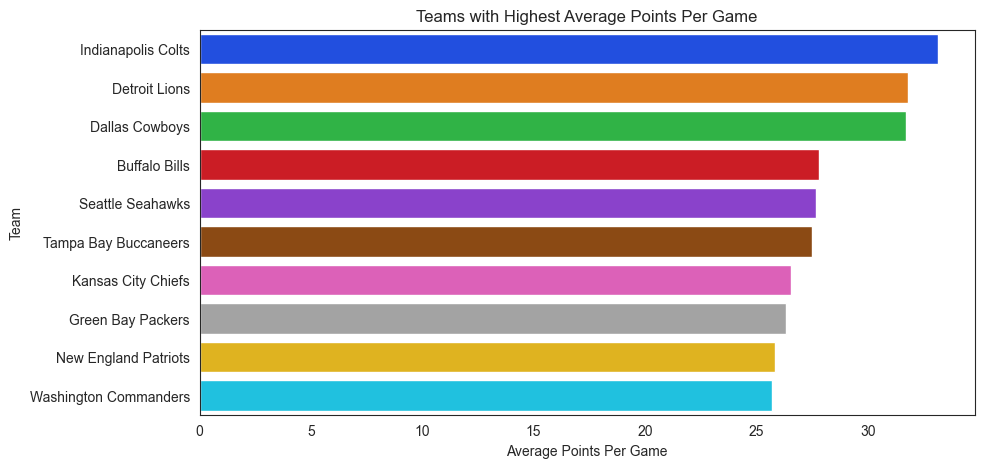

In [ ]:
# Horizontal Bar Chart
plt.figure(figsize=(10,5))  
sns.barplot(
    data=avg_pts_df,
    y='team_name',
    x='pts_avg',
    hue= 'team_name',
    palette=sns.color_palette('bright'),
    errorbar=None
)
plt.title('Teams with Highest Average Points Per Game')
plt.xlabel('Average Points Per Game')
plt.ylabel('Team')
plt.show()


## 2. Road Game Efficency
#### Which teams have the most wins and total scored points on the road this season?

### Analysis

In [11]:
road_game_query = """ 
    SELECT t.team_name, COUNT(g.season_week) AS away_games, t.away_wins, SUM(s.points_scored) AS total_away_pts
    FROM teams AS t
    JOIN stats AS s 
        ON t.team_id  = s.team_id 
    JOIN games AS g
        ON s.game_id = g.game_id
    WHERE t.team_id = g.away_team_id 
    GROUP BY t.team_name, t.away_wins
    ORDER BY t.team_name ;
"""

road_games_df: pd.DataFrame = pd.read_sql(road_game_query, engine)
road_games_df.sort_values(by='away_wins', ascending=False).head(10)


,team_name,away_games,away_wins,total_away_pts
21,New England Patriots,4,4,112.0
25,Philadelphia Eagles,4,3,96.0
29,Tampa Bay Buccaneers,3,3,81.0
27,San Francisco 49ers,4,3,88.0
18,Los Angeles Rams,4,3,111.0
28,Seattle Seahawks,3,3,74.0
5,Chicago Bears,3,2,71.0
13,Indianapolis Colts,3,2,99.0
17,Los Angeles Chargers,3,2,67.0
20,Minnesota Vikings,3,2,69.0


### Visuals

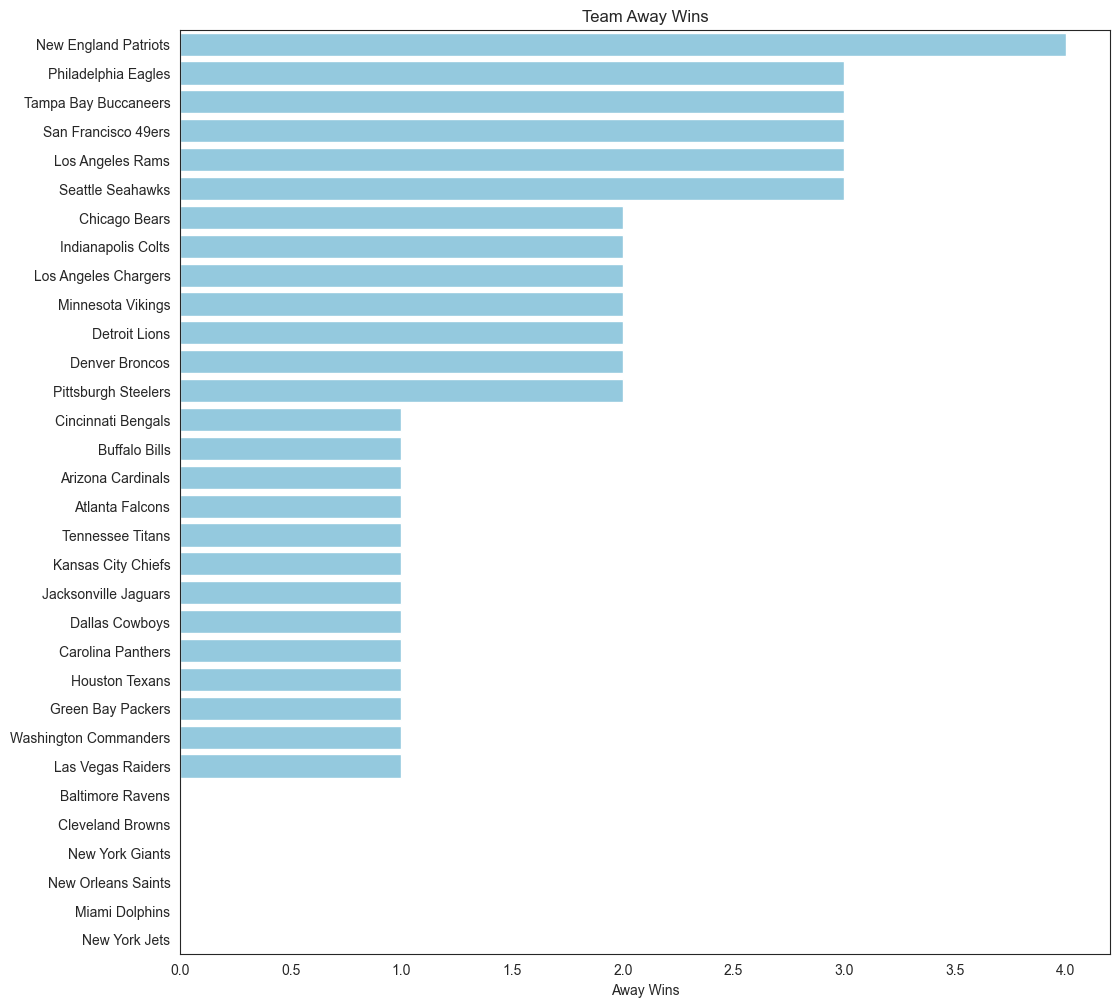

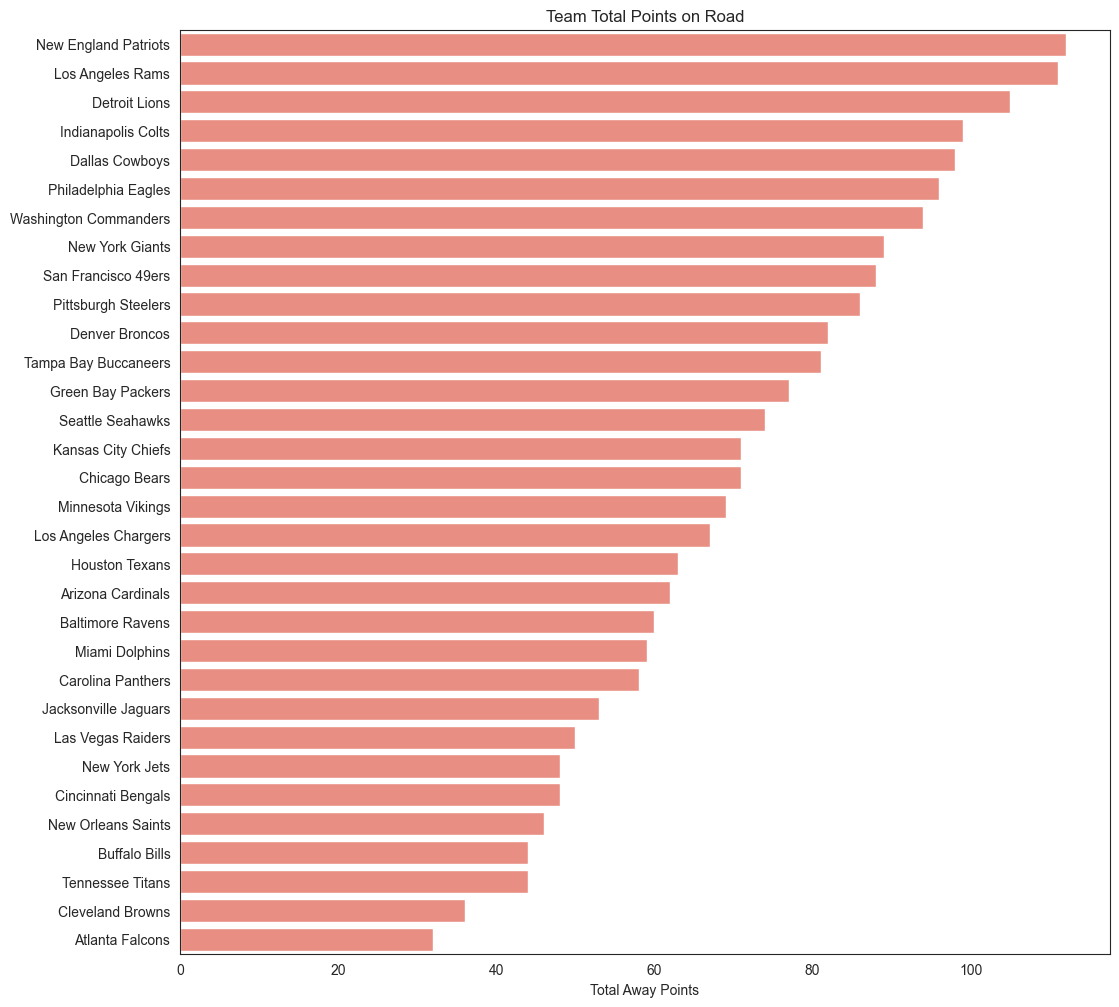

In [ ]:
# Horizontal Bar Chart
plt.figure(figsize=(12,12))
sns.barplot(
    data=road_games_df.sort_values('away_wins', ascending=False), 
    y='team_name', 
    x='away_wins', 
    color='skyblue'
)
plt.title('Team Away Wins')
plt.xlabel('Away Wins')
plt.ylabel('Teams')
plt.show()

# Horizontal Bar Chart
plt.figure(figsize=(12,12))
sns.barplot(
    data=road_games_df.sort_values('total_away_pts', ascending=False), 
    y='team_name', 
    x='total_away_pts', 
    color='salmon'
)
plt.title('Team Total Points on Road')
plt.xlabel('Total Away Points')
plt.ylabel('Teams')
plt.show()

## 3. Game Leaders
#### Who are the top players for each of the three game leader positions (QB, RB, WR) appeared most frequently as game leaders this season?

### Analysis

In [88]:
leaders_query = """ 
    SELECT player_name, position, category_name, leader_count
    FROM (
        SELECT 
            p.player_name,
            p.position,
            l.category_name,
            COUNT(l.player_id) AS leader_count,
            DENSE_RANK() OVER (
                PARTITION BY l.category_name   
                ORDER BY COUNT(l.player_id) DESC
            ) AS rnk
        FROM players AS p
        JOIN leaders AS l
            ON p.player_id = l.player_id
        GROUP BY p.player_name, p.position, l.category_name
    ) ranked
    WHERE rnk = 1
    ORDER BY category_name;
"""

leaders_df: pd.DataFrame = pd.read_sql(leaders_query, engine)
leaders_df.head(10)

,player_name,position,category_name,leader_count
0,Justin Herbert,QB,Passing Leader,6
1,Patrick Mahomes,QB,Passing Leader,6
2,Jaxon Smith-Njigba,WR,Receiving Leader,5
3,Ashton Jeanty,RB,Rushing Leader,5
4,Kyren Williams,RB,Rushing Leader,5
5,Jonathan Taylor,RB,Rushing Leader,5


### Visuals

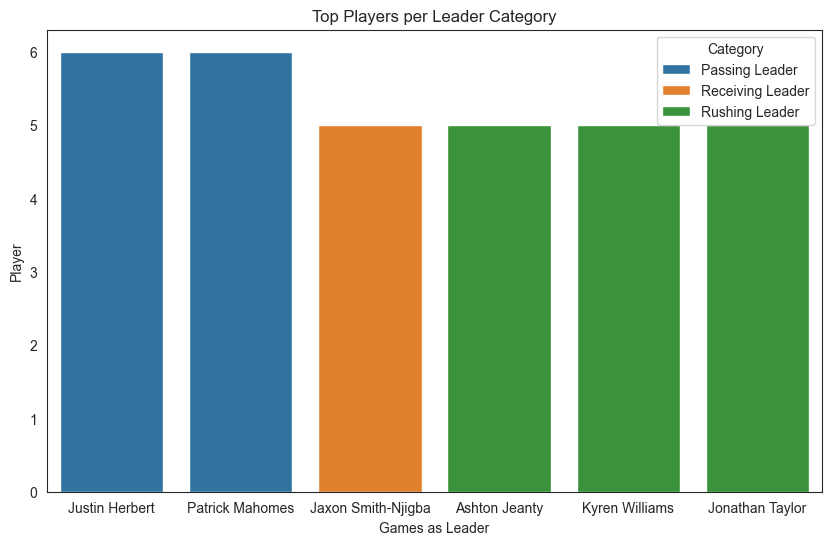

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=leaders_df,
    x='player_name',
    y='leader_count',
    hue='category_name',
    dodge=False  # stack players per category if needed
)
plt.xlabel('Games as Leader')
plt.ylabel('Player')
plt.title('Top Players per Leader Category')
plt.legend(title='Category')
plt.show()


## 4. Most Attended Games
#### Which teams have most fans attending their home games on average this season?

### Analysis

In [47]:
attendance_query = """ 
    SELECT t.team_name, ROUND(AVG(g.attendance), 2) AS avg_game_attendance
    FROM teams AS t
    JOIN games AS g
        ON t.team_id = g.home_team_id
    GROUP BY t.team_name
    ORDER BY avg_game_attendance DESC;
"""

attendance_df: pd.DataFrame = pd.read_sql(attendance_query, engine)
attendance_df.head(32)

,team_name,avg_game_attendance
0,Dallas Cowboys,93061.67
1,New York Giants,81402.67
2,Green Bay Packers,77601.67
3,New York Jets,75613.60
4,Denver Broncos,75069.33
5,Kansas City Chiefs,73559.25
6,Los Angeles Rams,72085.00
7,Atlanta Falcons,71723.00
8,Carolina Panthers,71683.00
9,Houston Texans,70989.00


### Visuals

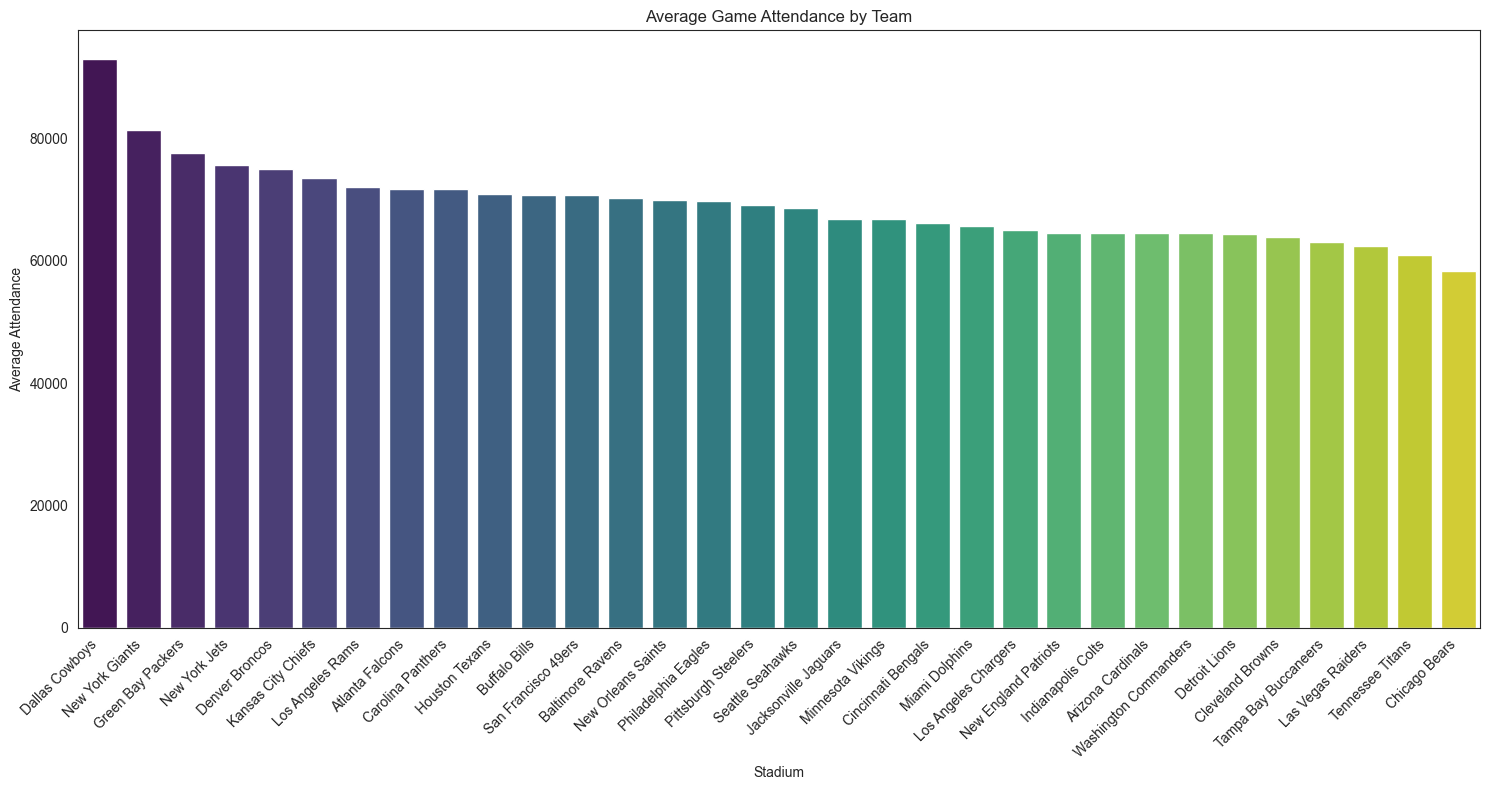

In [58]:
plt.figure(figsize=(15,8))
sns.barplot(data=attendance_df, 
    x='team_name', 
    y='avg_game_attendance', 
    palette='viridis',
    hue= 'team_name',
    errorbar=None
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Attendance')
plt.xlabel('Stadium')
plt.title('Average Game Attendance by Team')
plt.tight_layout()
plt.show()

## 5. Highest Scoring Games
#### What are the top 10 highest scoring games of the season?

### Analysis

In [75]:
combined_pts_query = """ 
    SELECT
        week,
        away_team_name,
        home_team_name,
        (home_team_points + away_team_points) AS total_points
    FROM (
        SELECT 
            g.season_week AS week,
            away_team.team_name AS away_team_name,
            away_stats.points_scored AS away_team_points,
            home_team.team_name AS home_team_name,
            home_stats.points_scored AS home_team_points
        FROM games AS g
        JOIN teams AS home_team
            ON g.home_team_id = home_team.team_id
        JOIN teams AS away_team
            ON g.away_team_id = away_team.team_id
        JOIN stats AS home_stats
            ON g.game_id = home_stats.game_id
            AND home_stats.team_id = g.home_team_id
        JOIN stats AS away_stats
            ON g.game_id = away_stats.game_id
            AND away_stats.team_id = g.away_team_id
    ) AS game_points
    ORDER BY total_points DESC
    LIMIT 10;
"""


combined_pts_df: pd.DataFrame = pd.read_sql(combined_pts_query, engine)

# Extract just name of team w/o city
combined_pts_df['away_team_name'] = combined_pts_df['away_team_name'].str.split().str[-1]
combined_pts_df['home_team_name'] = combined_pts_df['home_team_name'].str.split().str[-1]

combined_pts_df['matchup'] = combined_pts_df['away_team_name'] + " @ " + combined_pts_df['home_team_name']
combined_pts_df.head(50)



,week,away_team_name,home_team_name,total_points,matchup
0,1,Ravens,Bills,81,Ravens @ Bills
1,4,Packers,Cowboys,80,Packers @ Cowboys
2,2,Giants,Cowboys,77,Giants @ Cowboys
3,2,Bears,Lions,73,Bears @ Lions
4,5,Buccaneers,Seahawks,73,Buccaneers @ Seahawks
5,3,Lions,Ravens,68,Lions @ Ravens
6,1,Steelers,Jets,66,Steelers @ Jets
7,7,Commanders,Cowboys,66,Commanders @ Cowboys
8,7,Giants,Broncos,65,Giants @ Broncos
9,3,Raiders,Commanders,65,Raiders @ Commanders


### Visuals

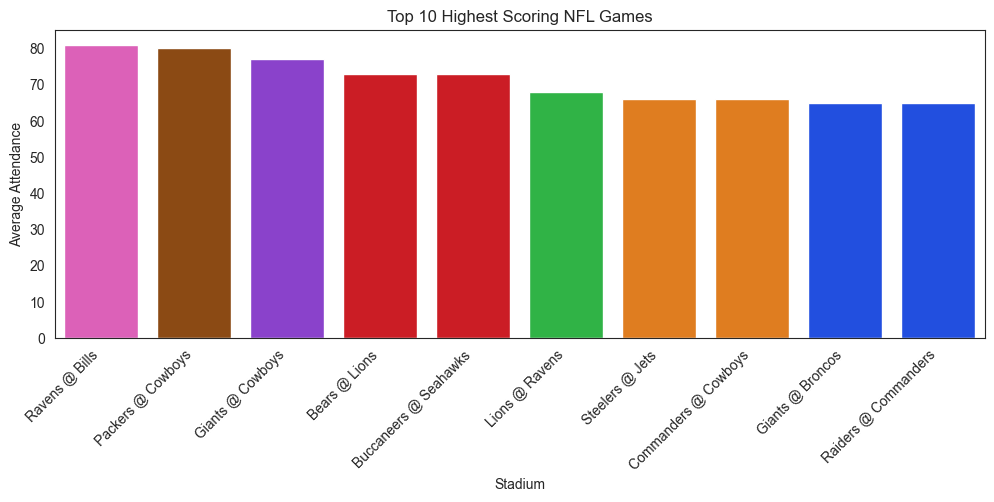

In [85]:

plt.figure(figsize=(12, 4))
sns.barplot(
    data=combined_pts_df,
    x='matchup',
    y='total_points',
    palette='bright',
    hue= 'total_points',
    errorbar=None,
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Attendance')
plt.xlabel('Stadium')
plt.title("Top 10 Highest Scoring NFL Games")
plt.show()
